## Support Vecter Machines

### Data

In [2]:
import numpy as np
import pandas as pd

load_df = pd.read_csv("data/force/f_train.csv")
drop_columns = ['RSHA', 'RMED', 'GR', 'PEF', 'SP', 'ROP', 'DRHO', 'RDEP', 'WELL']
load_df = load_df.drop(drop_columns, axis=1)
load_df = load_df.dropna()
df = load_df.copy()

# Categorize Lithology
litho_code = {30000: "Sandstone", 65030: "SandstoneShale", 65000: "Shale", 80000: "Marl", 
            74000: "Dolomite", 70000: "Limestone", 70032: "Chalk", 88000: "Halite", 
            86000: "Anhydrite", 99000: "Tuff", 90000: "Coal", 93000: "Basement"}
df["LITHOLOGY"] = df["LITHOLOGY"].map(litho_code)

df = df[df.LITHOLOGY != "Shale"]
df = df.reset_index(drop=True)

drop = ['GROUP', 'FORMATION', 'BS']
dt_df = df.drop(drop, axis=1)

# Select sample that Litho is in ['Limestone', 'SandstoneShale']
# dt_df = dt_df[dt_df["LITHOLOGY"].isin(["Limestone", "SandstoneShale"])]
dt_df = dt_df.reset_index(drop=True)
dtdfraw = dt_df.copy()
dt_df.head(10)

,DEPTH_MD,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,1151.928,17.363323,2.000440,0.589035,133.393707,SandstoneShale
1,1152.080,17.306395,2.007255,0.595443,135.019684,SandstoneShale
2,1152.232,17.303955,2.017085,0.610448,136.660767,SandstoneShale
3,1152.384,17.368221,2.027622,0.614587,136.615814,SandstoneShale
4,1152.536,17.433296,2.033576,0.600994,134.936020,SandstoneShale
5,1159.376,17.332830,1.993782,0.633213,141.699799,SandstoneShale
6,1159.528,17.305010,1.981597,0.596889,141.424210,SandstoneShale
7,1160.440,17.648685,1.926005,0.550250,140.952103,SandstoneShale
8,1160.592,17.555012,1.899559,0.561272,142.641083,SandstoneShale
9,1168.344,17.534988,2.004711,0.587427,138.450134,SandstoneShale


In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = dt_df.drop(['LITHOLOGY'], axis=1)
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=dt_df.columns[:-1])
dt_df[['DEPTH_MD', 'CALI', 'RHOB', 'NPHI', 'DTC']] = X

le = LabelEncoder()
dt_df['LITHOLOGY'] = le.fit_transform(dt_df['LITHOLOGY'])
dt_df.LITHOLOGY.value_counts()
dt_df.head(10)

,DEPTH_MD,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,-2.641126,2.674723,-1.655981,2.793521,2.387427,6
1,-2.640860,2.652519,-1.625451,2.846241,2.470655,6
2,-2.640594,2.651568,-1.581413,2.969684,2.554656,6
3,-2.640328,2.676633,-1.534211,3.003731,2.552355,6
4,-2.640062,2.702014,-1.507539,2.891905,2.466372,6
5,-2.628094,2.662830,-1.685809,3.156966,2.812585,6
6,-2.627828,2.651979,-1.740396,2.858134,2.798479,6
7,-2.626232,2.786021,-1.989445,2.474453,2.774314,6
8,-2.625966,2.749486,-2.107920,2.565125,2.860766,6
9,-2.612403,2.741676,-1.636848,2.780293,2.646247,6


In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(dt_df.drop('LITHOLOGY', axis=1))
scaled_df = pd.DataFrame(scaled_features, columns=dt_df.columns[:-1])
scaled_df['LITHOLOGY'] = dt_df['LITHOLOGY'].values
scaled_df.head(10)

,DEPTH_MD,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,0.000000,0.609454,0.417278,0.724849,0.697913,1
1,0.000059,0.605952,0.421766,0.733094,0.710956,1
2,0.000118,0.605802,0.428240,0.752399,0.724119,1
3,0.000177,0.609755,0.435180,0.757723,0.723759,1
4,0.000236,0.613757,0.439101,0.740235,0.710284,1
5,0.002895,0.607578,0.412892,0.781688,0.764539,1
6,0.002954,0.605867,0.404867,0.734954,0.762328,1
7,0.003308,0.627004,0.368252,0.674950,0.758541,1
8,0.003367,0.621243,0.350834,0.689131,0.772089,1
9,0.006380,0.620011,0.420091,0.722780,0.738472,1


### Train Test Splitting

In [5]:
from sklearn.model_selection import train_test_split
X = scaled_df.drop('LITHOLOGY', axis=1)
y = scaled_df['LITHOLOGY']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Modeling

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

def train_and_evaluate_svm(C, kernel='linear'):
    svm_model = SVC(kernel=kernel, C=C, random_state=42)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

Cs = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
for C in Cs:
    accuracy = train_and_evaluate_svm(C)
    print(f"SVM with C={C}: Accuracy = {accuracy:.4f}")

SVM with C=0.1: Accuracy = 0.6197
SVM with C=0.5: Accuracy = 0.6762
SVM with C=1.0: Accuracy = 0.6798
SVM with C=2.0: Accuracy = 0.6852
SVM with C=3.0: Accuracy = 0.6880
SVM with C=5.0: Accuracy = 0.6898
SVM with C=7.0: Accuracy = 0.6916
SVM with C=10.0: Accuracy = 0.6977


In [7]:
def plot_classification_report(report, title='Classification Report'):
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap='Blues', fmt='.2f', cbar=False)
    plt.title(title)
    plt.xlabel('Metrics')
    plt.ylabel('Classes')
    plt.gca().xaxis.set_label_position('top')  # Move x-axis label to the top
    plt.gca().xaxis.tick_top()  # Move x-axis ticks to the top
    plt.show()

def plot_confusion_matrix(y_test, y_pred, labels, title='Confusion Matrix for SVM Model'):
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix
    
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
    plt.show()

### Linear Kernel, C = 0.1

SVM Model Accuracy: 0.6196779964221825


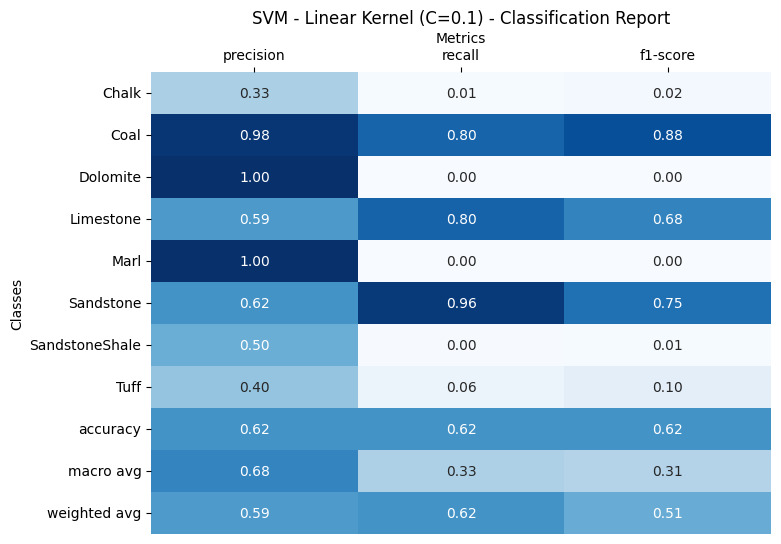

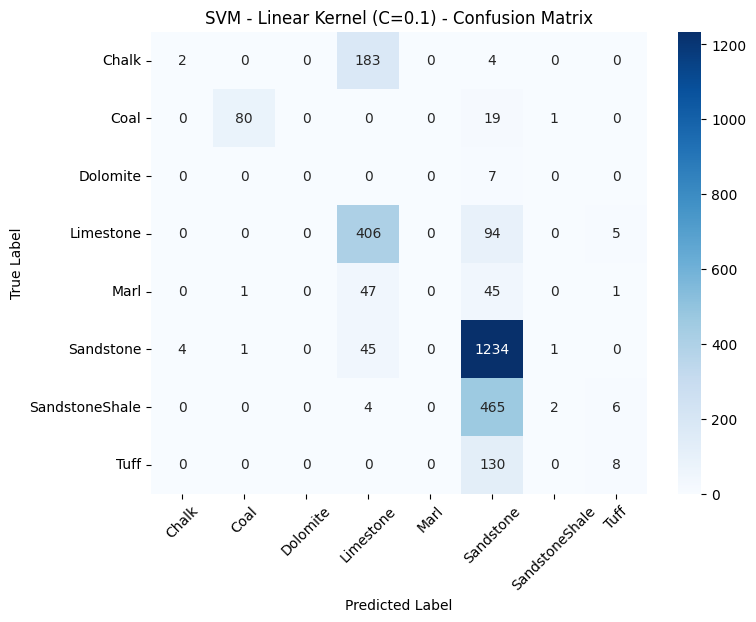

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='linear', C=0.1, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
linear_svm_accuracy_c01 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", linear_svm_accuracy_c01)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
plot_classification_report(classification_rp, title='SVM - Linear Kernel (C=0.1) - Classification Report')
plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - Linear Kernel (C=0.1) - Confusion Matrix')

### Linear Kernel, C = 1.0

SVM Model Accuracy: 0.6797853309481217


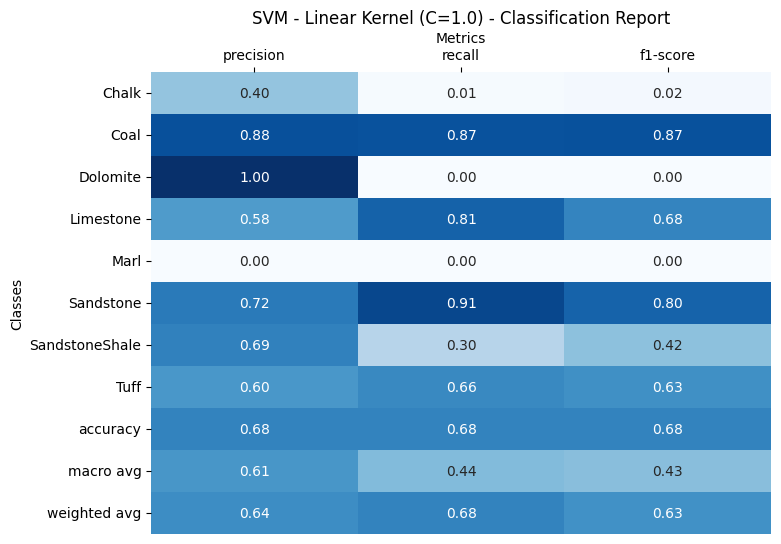

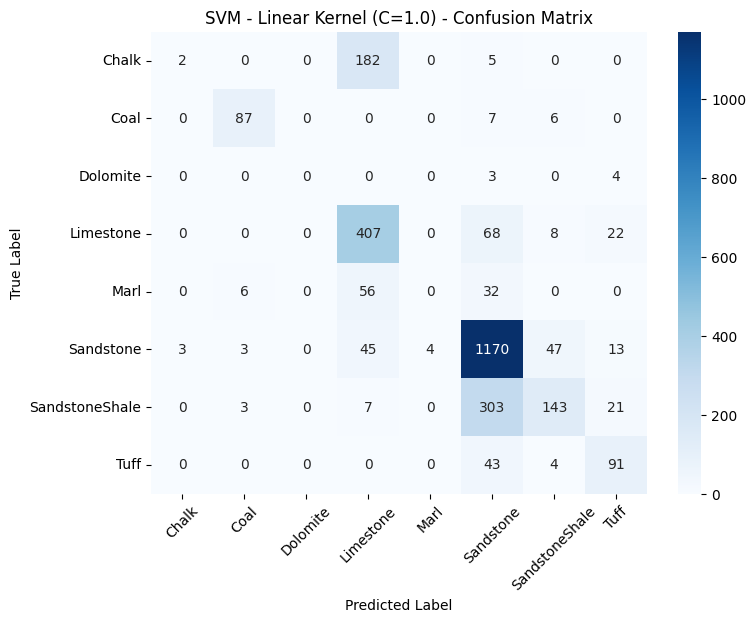

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='linear', C=1, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
linear_svm_accuracy_c10 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", linear_svm_accuracy_c10)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
plot_classification_report(classification_rp, title='SVM - Linear Kernel (C=1.0) - Classification Report')
plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - Linear Kernel (C=1.0) - Confusion Matrix')

### Linear Kernel, C = 7.0

SVM Model Accuracy: 0.6915921288014312


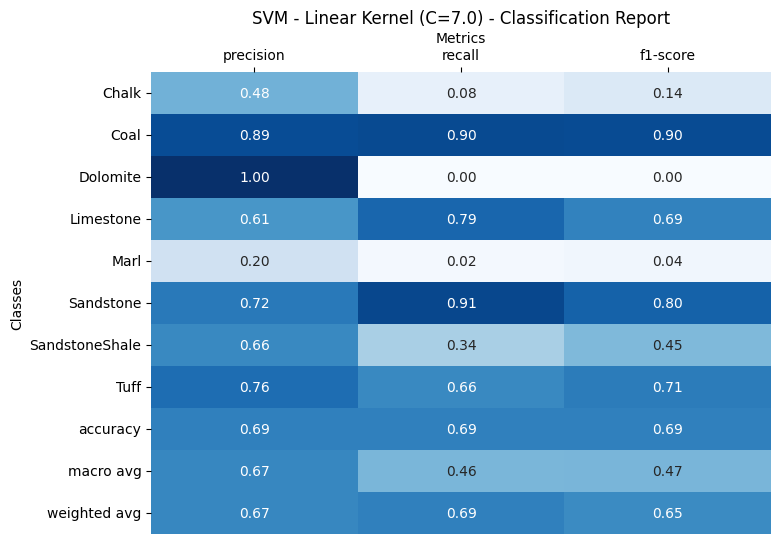

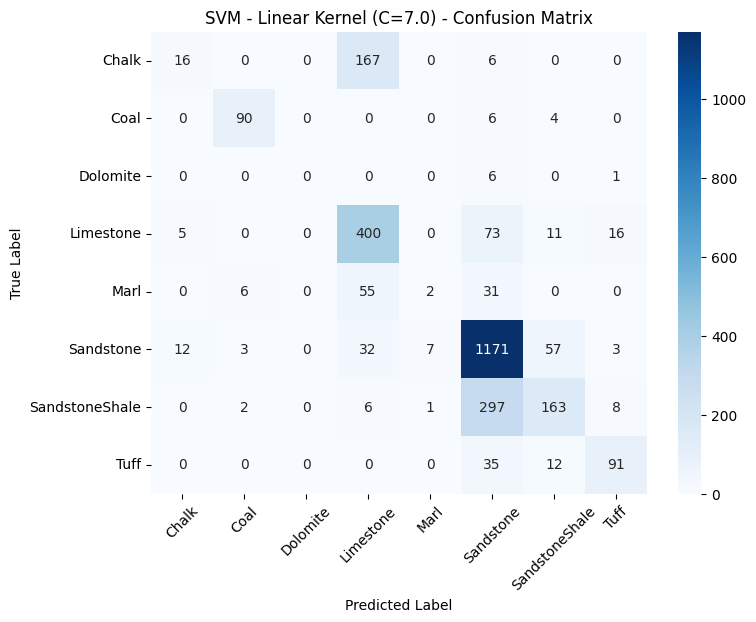

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='linear', C=7, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
linear_svm_accuracy_c70 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", linear_svm_accuracy_c70)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
plot_classification_report(classification_rp, title='SVM - Linear Kernel (C=7.0) - Classification Report')
plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - Linear Kernel (C=7.0) - Confusion Matrix')

### Polynomial Kernel

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def train_and_evaluate_svm(C, kernel='poly', degree=3):
    svm_model = SVC(kernel=kernel, C=C, degree=degree, random_state=42)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [12]:
Cs = [0.1, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0]
for C in Cs:
    accuracy = train_and_evaluate_svm(C, kernel='poly')
    print(f"SVM with C={C}: Accuracy = {accuracy:.4f}")

SVM with C=0.1: Accuracy = 0.7853
SVM with C=0.5: Accuracy = 0.8150
SVM with C=1.0: Accuracy = 0.8250
SVM with C=1.5: Accuracy = 0.8297
SVM with C=2.0: Accuracy = 0.8340
SVM with C=3.0: Accuracy = 0.8390
SVM with C=5.0: Accuracy = 0.8429
SVM with C=7.0: Accuracy = 0.8469
SVM with C=10.0: Accuracy = 0.8476


In [13]:
degrees = [2, 3, 4, 5, 6]
for degree in degrees:
    accuracy = train_and_evaluate_svm(C=1.0, kernel='poly', degree=degree)
    print(f"SVM with degree={degree}: Accuracy = {accuracy:.4f}")

SVM with degree=2: Accuracy = 0.7925
SVM with degree=3: Accuracy = 0.8250
SVM with degree=4: Accuracy = 0.8497
SVM with degree=5: Accuracy = 0.8633
SVM with degree=6: Accuracy = 0.8698


### Polynomial Kernel C=1 degree=2

SVM Model Accuracy: 0.7924865831842576


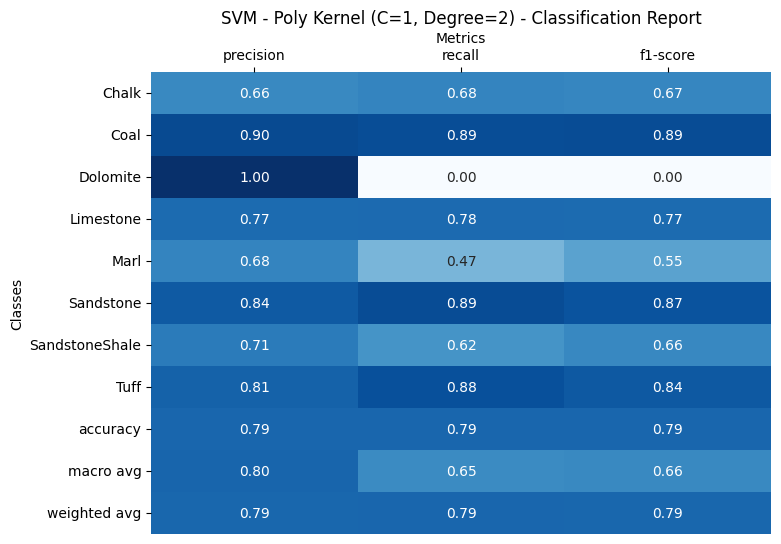

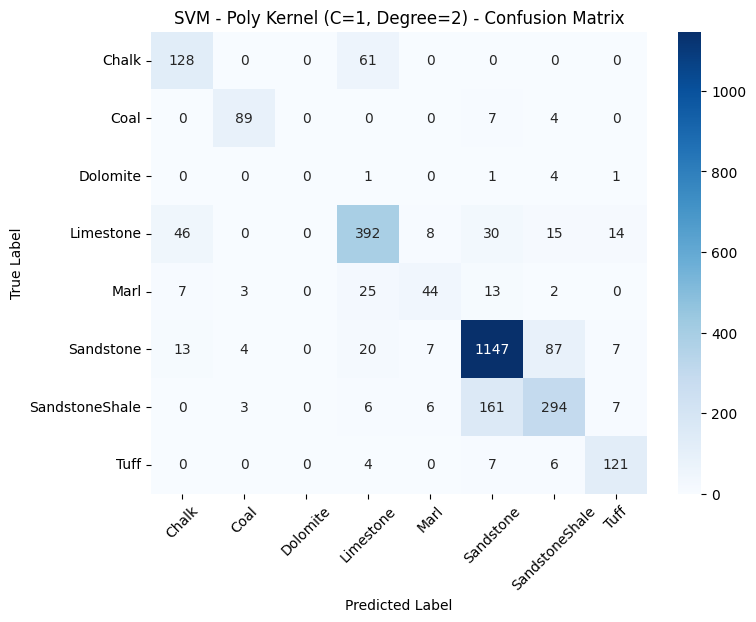

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='poly', C=1, degree=2, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
poly_svm_accuracy_C12 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", poly_svm_accuracy_C12)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
plot_classification_report(classification_rp, title='SVM - Poly Kernel (C=1, Degree=2) - Classification Report')
plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - Poly Kernel (C=1, Degree=2) - Confusion Matrix')

### Polynomial Kernel C=2 degree=3

SVM Model Accuracy: 0.8339892665474061


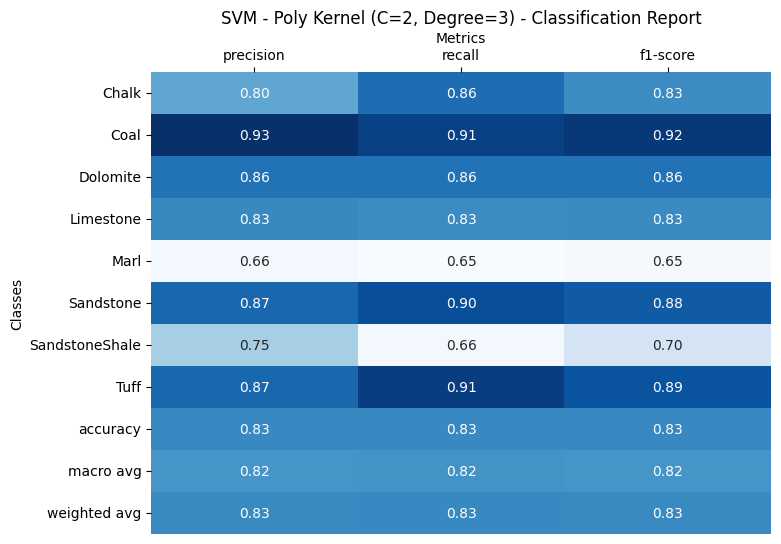

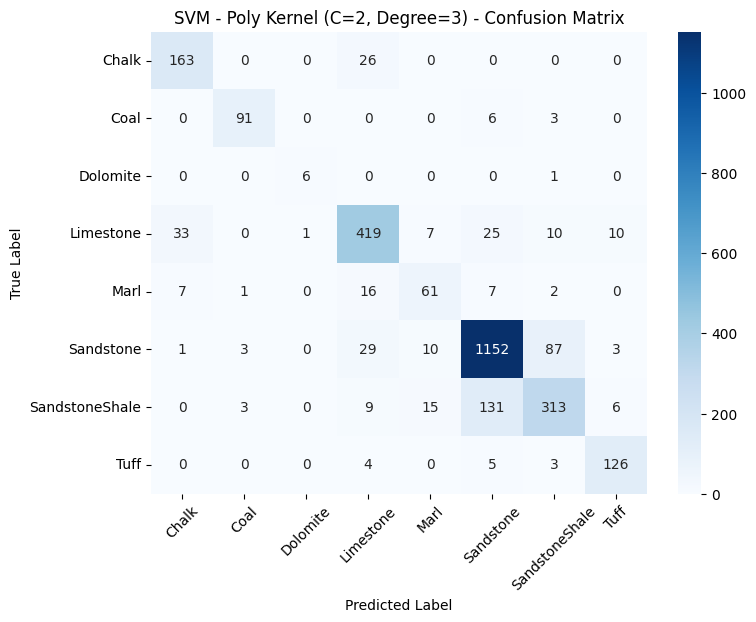

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='poly', C=2, degree=3, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
poly_svm_accuracy_C23 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", poly_svm_accuracy_C23)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
plot_classification_report(classification_rp, title='SVM - Poly Kernel (C=2, Degree=3) - Classification Report')
plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - Poly Kernel (C=2, Degree=3) - Confusion Matrix')

### Polynomial Kernel C=3 degree=5

SVM Model Accuracy: 0.8644007155635063


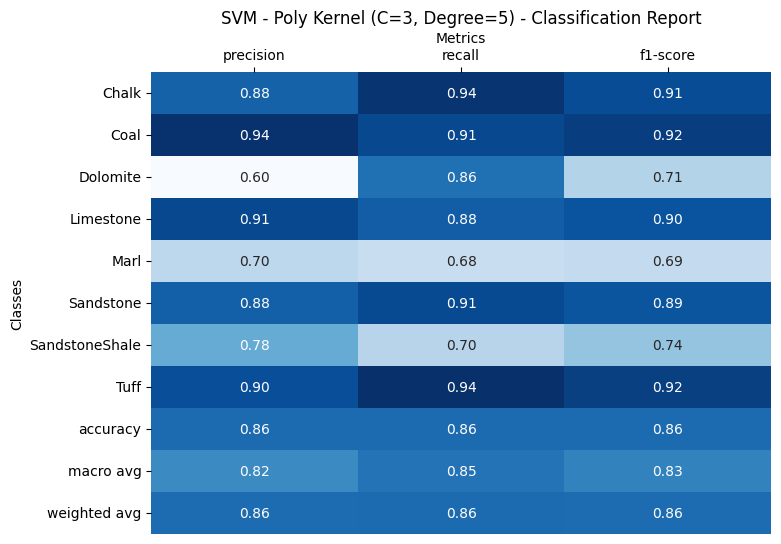

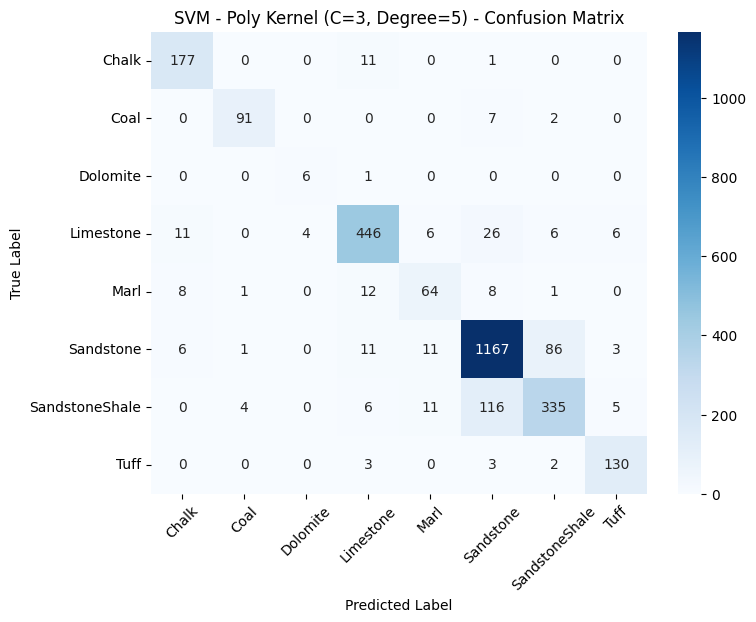

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='poly', C=3, degree=5, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
poly_svm_accuracy_C35 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", poly_svm_accuracy_C35)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
plot_classification_report(classification_rp, title='SVM - Poly Kernel (C=3, Degree=5) - Classification Report')
plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - Poly Kernel (C=3, Degree=5) - Confusion Matrix')

### RBF Kernel

In [17]:
def train_and_evaluate_svm(C, kernel='rbf'):
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score
    svm_model = SVC(kernel=kernel, C=C, random_state=42)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

Cs = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
for C in Cs:
    accuracy = train_and_evaluate_svm(C)
    print(f"RBF SVM with C={C}: Accuracy = {accuracy:.4f}")

RBF SVM with C=0.1: Accuracy = 0.7177
RBF SVM with C=0.5: Accuracy = 0.7918
RBF SVM with C=1.0: Accuracy = 0.8261
RBF SVM with C=2.0: Accuracy = 0.8322
RBF SVM with C=3.0: Accuracy = 0.8404
RBF SVM with C=5.0: Accuracy = 0.8451
RBF SVM with C=7.0: Accuracy = 0.8512
RBF SVM with C=10.0: Accuracy = 0.8540


### RBF Kernel C = 0.1

SVM Model Accuracy: 0.7177101967799642


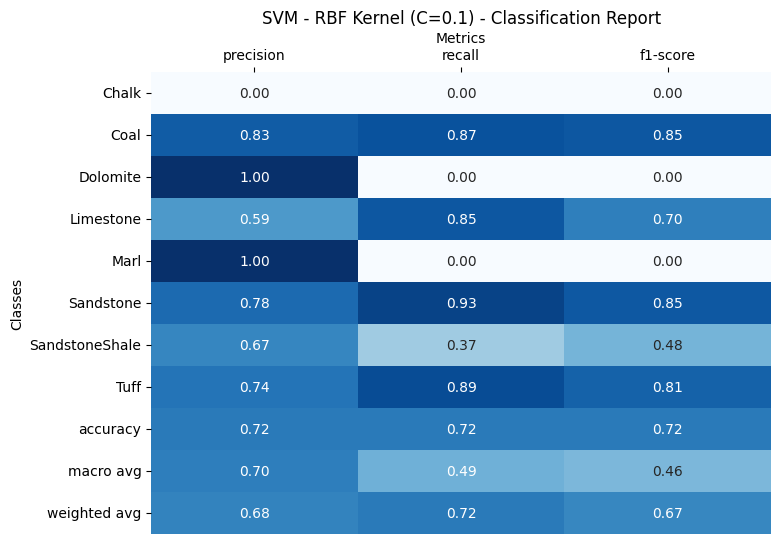

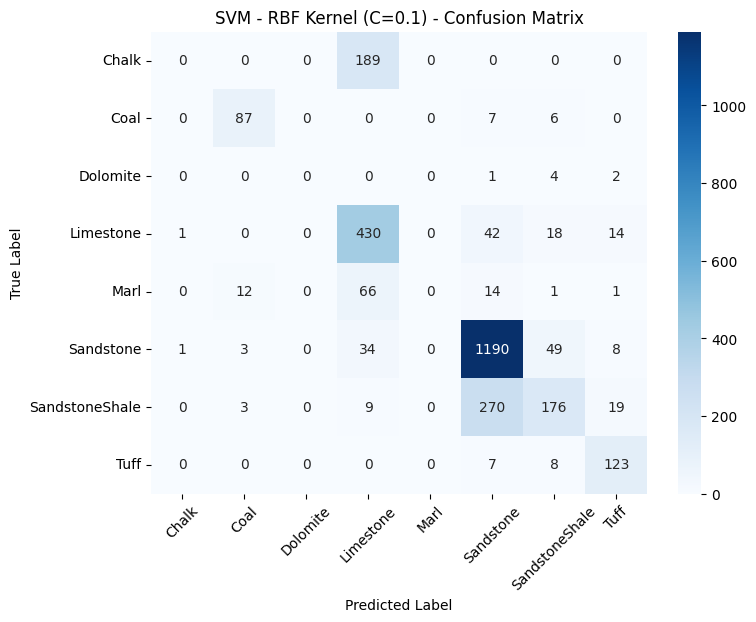

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', C=.1, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
rbf_svm_accuracy_C01 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", rbf_svm_accuracy_C01)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
plot_classification_report(classification_rp, title='SVM - RBF Kernel (C=0.1) - Classification Report')
plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - RBF Kernel (C=0.1) - Confusion Matrix')

### RBF Kernel C = 1.0

SVM Model Accuracy: 0.826118067978533


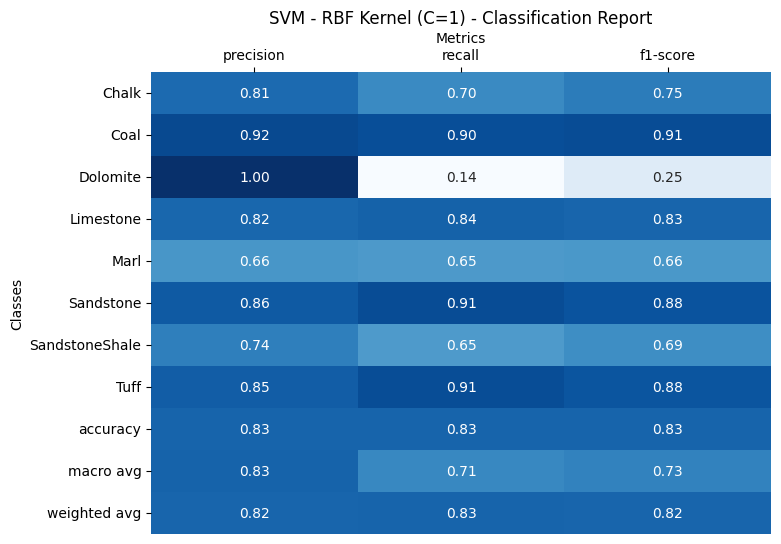

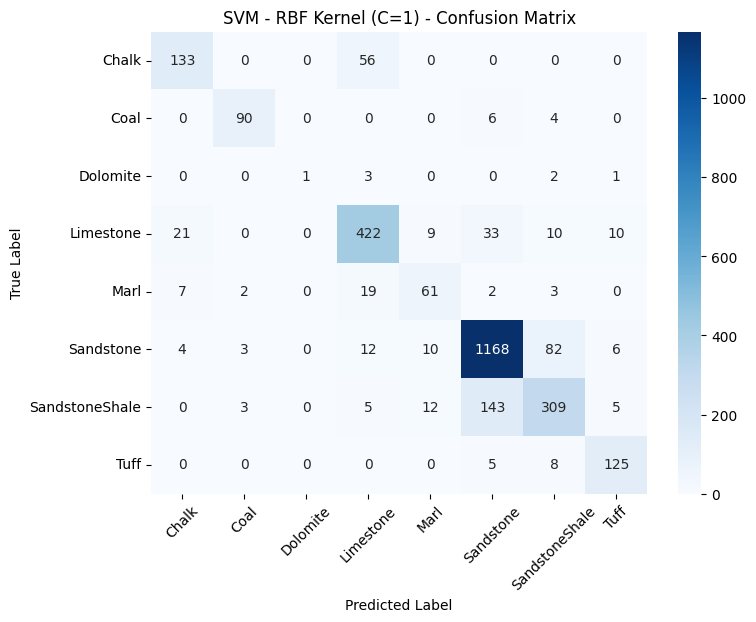

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', C=1, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
rbf_svm_accuracy_C1 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", rbf_svm_accuracy_C1)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
plot_classification_report(classification_rp, title='SVM - RBF Kernel (C=1) - Classification Report')
plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - RBF Kernel (C=1) - Confusion Matrix')

### RBF Kernel C = 3.0

SVM Model Accuracy: 0.8404293381037568


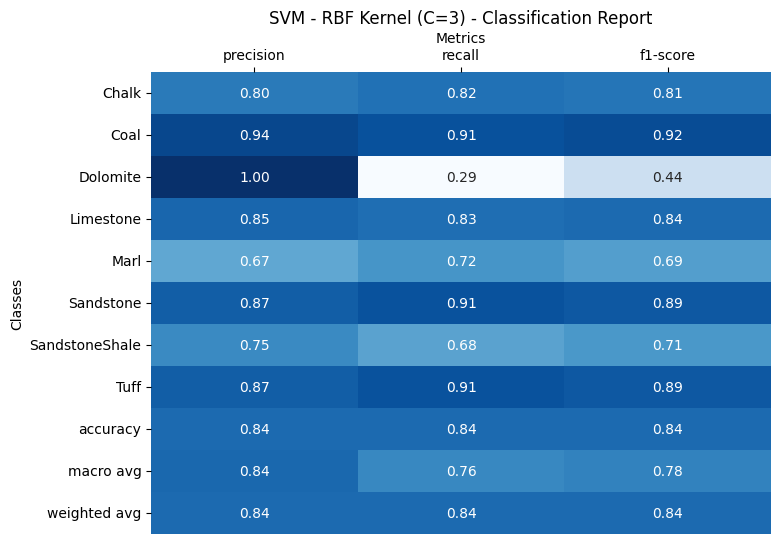

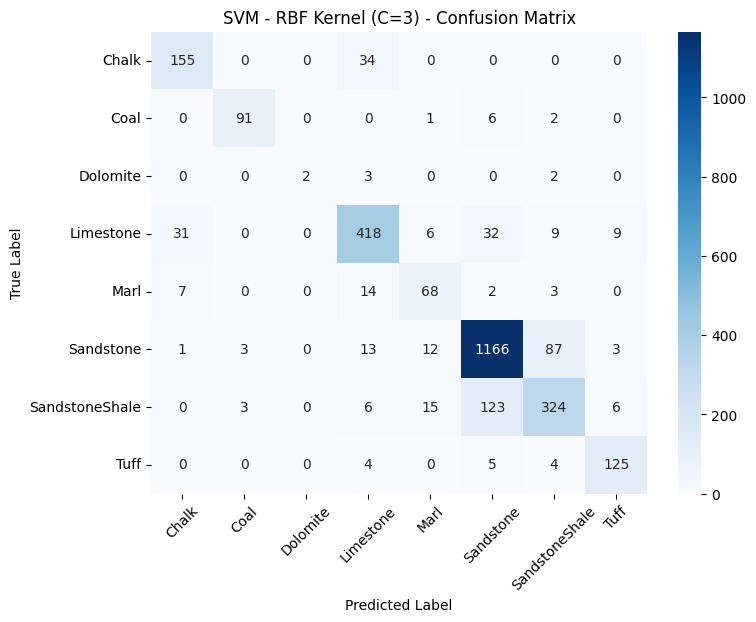

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', C=3, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
rbf_svm_accuracy_C3 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", rbf_svm_accuracy_C3)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
plot_classification_report(classification_rp, title='SVM - RBF Kernel (C=3) - Classification Report')
plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - RBF Kernel (C=3) - Confusion Matrix')

## Comparison

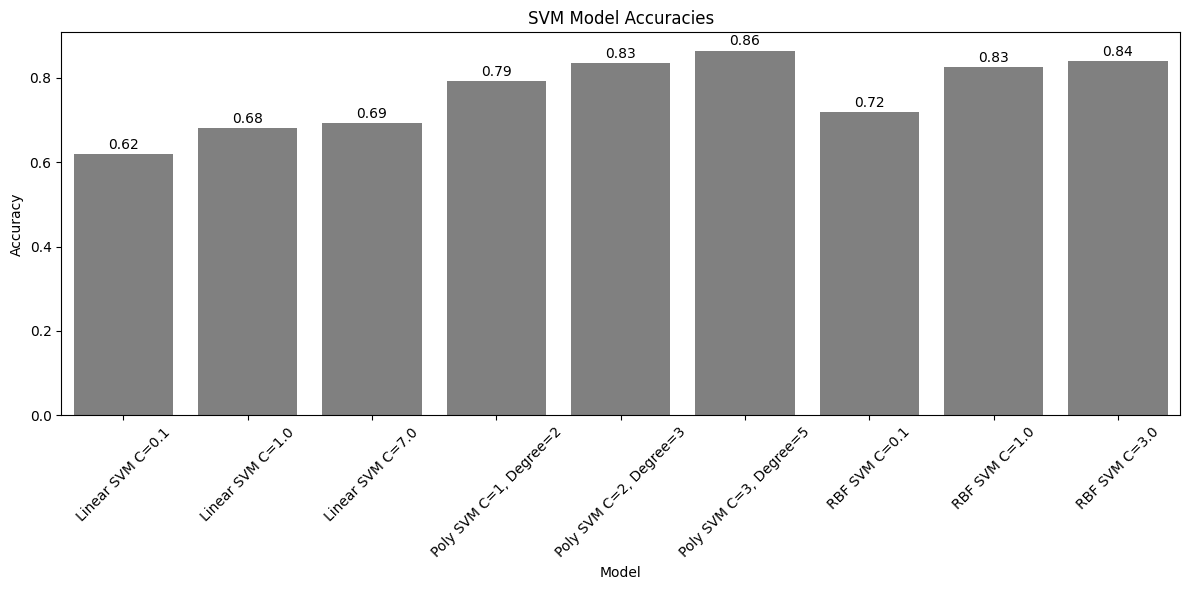

In [21]:
accuracies = {
    'Linear SVM C=0.1': linear_svm_accuracy_c01,
    'Linear SVM C=1.0': linear_svm_accuracy_c10,
    'Linear SVM C=7.0': linear_svm_accuracy_c70,
    'Poly SVM C=1, Degree=2': poly_svm_accuracy_C12,
    'Poly SVM C=2, Degree=3': poly_svm_accuracy_C23,
    'Poly SVM C=3, Degree=5': poly_svm_accuracy_C35,
    'RBF SVM C=0.1': rbf_svm_accuracy_C01,
    'RBF SVM C=1.0': rbf_svm_accuracy_C1,
    'RBF SVM C=3.0': rbf_svm_accuracy_C3
}
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), color='gray', alpha=1)
plt.title('SVM Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)

# Add value to top of the bar
for i, value in enumerate(accuracies.values()):
    plt.text(i, value + 0.005, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Visualization of Decision Boundary

In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

load_df = pd.read_csv("data/force/f_train.csv")
drop_columns = ['RSHA', 'RMED', 'GR', 'PEF', 'SP', 'ROP', 'DRHO', 'RDEP', 'WELL']
load_df = load_df.drop(drop_columns, axis=1)
load_df = load_df.dropna()
df = load_df.copy()

# Categorize Lithology
litho_code = {30000: "Sandstone", 65030: "SandstoneShale", 65000: "Shale", 80000: "Marl", 
            74000: "Dolomite", 70000: "Limestone", 70032: "Chalk", 88000: "Halite", 
            86000: "Anhydrite", 99000: "Tuff", 90000: "Coal", 93000: "Basement"}
df["LITHOLOGY"] = df["LITHOLOGY"].map(litho_code)

df = df[df.LITHOLOGY != "Shale"]
df = df.reset_index(drop=True)

drop = ['GROUP', 'FORMATION', 'BS']
dt_df = df.drop(drop, axis=1)

# Select sample that Litho is in ['Limestone', 'SandstoneShale']
dt_df = dt_df[dt_df["LITHOLOGY"].isin(["Limestone", "SandstoneShale"])]
dt_df = dt_df.reset_index(drop=True)
dtdfraw = dt_df.copy()

scaler = StandardScaler()
X = dt_df.drop(['LITHOLOGY'], axis=1)
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=dt_df.columns[:-1])
dt_df[['DEPTH_MD', 'CALI', 'RHOB', 'NPHI', 'DTC']] = X

le = LabelEncoder()
dt_df['LITHOLOGY'] = le.fit_transform(dt_df['LITHOLOGY'])
print(dt_df.LITHOLOGY.value_counts())
dt_df.head(10)

LITHOLOGY
0    2523
1    2386
Name: count, dtype: int64


,DEPTH_MD,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,-3.228020,2.763317,-2.470029,3.323737,2.653650,1
1,-3.227703,2.741020,-2.433525,3.382617,2.738361,1
2,-3.227386,2.740064,-2.380870,3.520485,2.823859,1
3,-3.227068,2.765235,-2.324432,3.558510,2.821518,1
4,-3.226751,2.790723,-2.292540,3.433618,2.734003,1
5,-3.212473,2.751374,-2.505694,3.729651,3.086386,1
6,-3.212155,2.740477,-2.570963,3.395901,3.072028,1
7,-3.210252,2.875083,-2.868745,2.967387,3.047432,1
8,-3.209934,2.838394,-3.010403,3.068654,3.135425,1
9,-3.193752,2.830552,-2.447153,3.308964,2.917083,1


In [23]:
label = "LITHOLOGY"
X_features = dt_df.drop(label, axis=1)
y_target = dt_df[label]

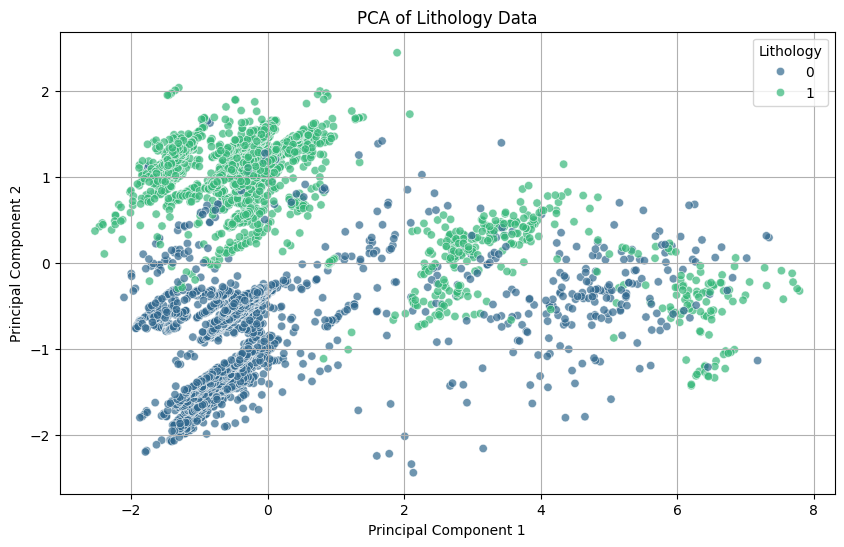

In [24]:
# PCA for 2 components
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)

# Convert X_pca to DataFrame and add labels
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['LITHOLOGY'] = y_target.values

# Plotting the PCA results
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='LITHOLOGY', palette='viridis', alpha=0.7)
plt.title('PCA of Lithology Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Lithology', loc='upper right')
plt.grid()
plt.show()

### Train Test Split

In [25]:
# Train test split
X_features = pca_df.drop('LITHOLOGY', axis=1)
y_target = pca_df['LITHOLOGY']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, 
                                                    random_state=42, stratify=y_target)

### Linear SVM C=1

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='linear', C=1, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
linear_svm_accuracy_c10 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", linear_svm_accuracy_c10)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
# plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - Linear Kernel (C=1.0) - Confusion Matrix')

SVM Model Accuracy: 0.9317718940936863


In [27]:
# calculate or extract the margin
def plot_margin(X, y, model, margin=None, title='Margin Plot'):
    plt.figure(figsize=(10, 6))
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, palette='viridis', edgecolor='k')
    plt.contour(xx, yy, Z, colors='red', levels=[0], linestyles=['-'])
    if margin:
        plt.contour(xx, yy, Z, colors='blue', levels=[-margin, margin], linestyles=['--'])
    
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(title='Lithology')
    plt.show()

In [28]:
# magrin value
def calculate_margin(model, X):
    support_vectors = model.support_vectors_
    margin = 1 / np.sqrt(np.sum(model.coef_ ** 2))
    return margin
margin_value = calculate_margin(svm_model, X_train)
print(f"Margin Value: {margin_value:.4f}")

Margin Value: 0.4737


/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


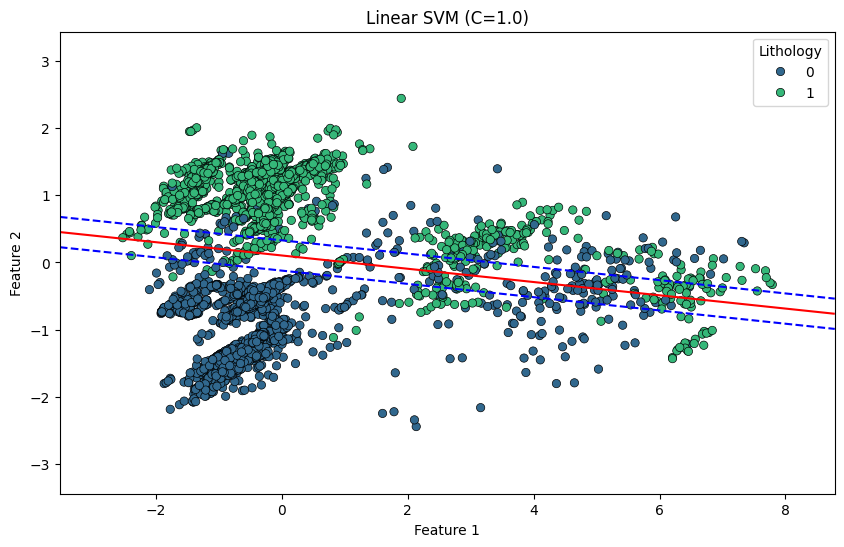

In [29]:
plot_margin(X_train, y_train, svm_model, margin=0.4737, title='Linear SVM (C=1.0)')

### Polynomial Kernel C=3 degree=5

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='poly', C=2, degree=3, random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
poly_svm_accuracy_C35 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", poly_svm_accuracy_C35)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
# plot_classification_report(classification_rp, title='SVM - Poly Kernel (C=3, Degree=5) - Classification Report')
# plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - Poly Kernel (C=3, Degree=5) - Confusion Matrix')

SVM Model Accuracy: 0.9063136456211812


/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


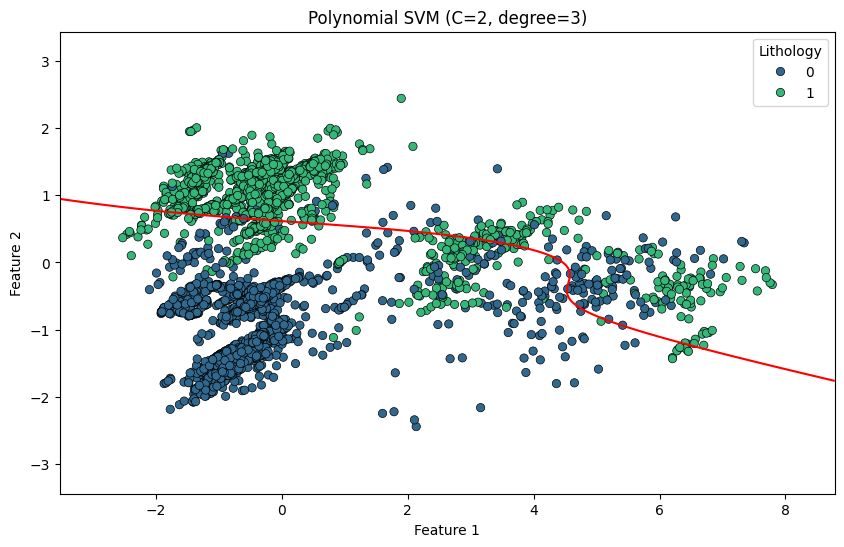

In [31]:
plot_margin(X_train, y_train, svm_model, title='Polynomial SVM (C=2, degree=3)')

### RBF Kernel C = 3.0

SVM Model Accuracy: 0.9653767820773931


/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


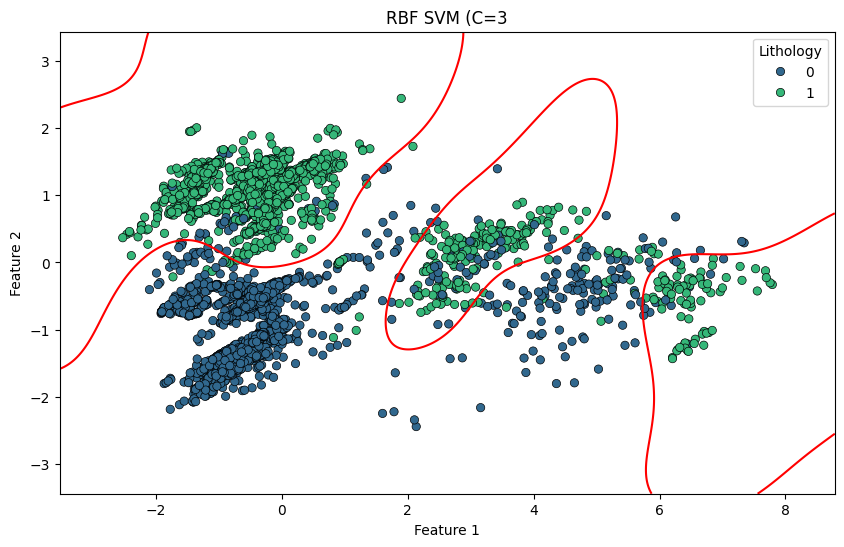

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', C=3, gamma='auto', random_state=42)
svm_model.fit(X_train, y_train)
# Evaluate the model
y_pred = svm_model.predict(X_test)

# Accuracy, Classification Report
rbf_svm_accuracy_C3 = accuracy_score(y_test, y_pred)
print("SVM Model Accuracy:", rbf_svm_accuracy_C3)
classification_rp = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1, output_dict=True)
# plot_classification_report(classification_rp, title='SVM - RBF Kernel (C=3) - Classification Report')
# plot_confusion_matrix(y_test, y_pred, labels=le.classes_, title='SVM - RBF Kernel (C=3) - Confusion Matrix')# 

plot_margin(X_train, y_train, svm_model, title='RBF SVM (C=3')
